## Generating text with Neural networks
<br>

    This is not generative Ai, this is a classification model. When the data is passed to the model, it performs sentiment classification. The output will have an entry for every word in the vocabulary. It will output the confidence of every word and then the ones with the highest probablities can be taken./

In [32]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

### Building the vocabulary

In [10]:
data = "In the town of Athy one Jeremy Lanigan \n Battered away til he hadnt a pound. \nHis father died and made him a man again \n Left him a farm and ten acres of ground. \nHe gave a grand party for friends and relations \nWho didnt forget him when come to the wall, \nAnd if youll but listen Ill make your eyes glisten \nOf the rows and the ructions of Lanigans Ball. \nMyself to be sure got free invitation, \nFor all the nice girls and boys I might ask, \nAnd just in a minute both friends and relations \nWere dancing round merry as bees round a cask. \nJudy ODaly, that nice little milliner, \nShe tipped me a wink for to give her a call, \nAnd I soon arrived with Peggy McGilligan \nJust in time for Lanigans Ball. \nThere were lashings of punch and wine for the ladies, \nPotatoes and cakes; there was bacon and tea, \nThere were the Nolans, Dolans, OGradys \nCourting the girls and dancing away. \nSongs they went round as plenty as water, \nThe harp that once sounded in Taras old hall,\nSweet Nelly Gray and The Rat Catchers Daughter,\nAll singing together at Lanigans Ball. \nThey were doing all kinds of nonsensical polkas \nAll round the room in a whirligig. \nJulia and I, we banished their nonsense \nAnd tipped them the twist of a reel and a jig. \nAch mavrone, how the girls got all mad at me \nDanced til youd think the ceiling would fall. \nFor I spent three weeks at Brooks Academy \nLearning new steps for Lanigans Ball. \nThree long weeks I spent up in Dublin, \nThree long weeks to learn nothing at all,\n Three long weeks I spent up in Dublin, \nLearning new steps for Lanigans Ball. \nShe stepped out and I stepped in again, \nI stepped out and she stepped in again, \nShe stepped out and I stepped in again, \nLearning new steps for Lanigans Ball. \nBoys were all merry and the girls they were hearty \nAnd danced all around in couples and groups, \nTil an accident happened, young Terrance McCarthy \nPut his right leg through miss Finnertys hoops. \nPoor creature fainted and cried Meelia murther, \nCalled for her brothers and gathered them all. \nCarmody swore that hed go no further \nTil he had satisfaction at Lanigans Ball. \nIn the midst of the row miss Kerrigan fainted, \nHer cheeks at the same time as red as a rose. \nSome of the lads declared she was painted, \nShe took a small drop too much, I suppose. \nHer sweetheart, Ned Morgan, so powerful and able, \nWhen he saw his fair colleen stretched out by the wall, \nTore the left leg from under the table \nAnd smashed all the Chaneys at Lanigans Ball. \nBoys, oh boys, twas then there were runctions. \nMyself got a lick from big Phelim McHugh. \nI soon replied to his introduction \nAnd kicked up a terrible hullabaloo. \nOld Casey, the piper, was near being strangled. \nThey squeezed up his pipes, bellows, chanters and all. \nThe girls, in their ribbons, they got all entangled \nAnd that put an end to Lanigans Ball."

corpus = data.lower().split("\n")
print(corpus)

['in the town of athy one jeremy lanigan ', ' battered away til he hadnt a pound. ', 'his father died and made him a man again ', ' left him a farm and ten acres of ground. ', 'he gave a grand party for friends and relations ', 'who didnt forget him when come to the wall, ', 'and if youll but listen ill make your eyes glisten ', 'of the rows and the ructions of lanigans ball. ', 'myself to be sure got free invitation, ', 'for all the nice girls and boys i might ask, ', 'and just in a minute both friends and relations ', 'were dancing round merry as bees round a cask. ', 'judy odaly, that nice little milliner, ', 'she tipped me a wink for to give her a call, ', 'and i soon arrived with peggy mcgilligan ', 'just in time for lanigans ball. ', 'there were lashings of punch and wine for the ladies, ', 'potatoes and cakes; there was bacon and tea, ', 'there were the nolans, dolans, ogradys ', 'courting the girls and dancing away. ', 'songs they went round as plenty as water, ', 'the harp tha

In [11]:
vectorize_layer = tf.keras.layers.TextVectorization()
vectorize_layer.adapt(corpus)

In [26]:
# Size of vocabulary
vocab_size = vectorize_layer.vocabulary_size()
vocabulary = vectorize_layer.get_vocabulary()
print(f"Vocabulary:\n {vectorize_layer.get_vocabulary()}")
print(f"\nVocabulary size: {vocab_size}")

Vocabulary:
 ['', '[UNK]', np.str_('and'), np.str_('the'), np.str_('a'), np.str_('in'), np.str_('all'), np.str_('i'), np.str_('for'), np.str_('of'), np.str_('lanigans'), np.str_('ball'), np.str_('were'), np.str_('at'), np.str_('to'), np.str_('stepped'), np.str_('she'), np.str_('they'), np.str_('his'), np.str_('girls'), np.str_('as'), np.str_('weeks'), np.str_('up'), np.str_('til'), np.str_('three'), np.str_('there'), np.str_('that'), np.str_('round'), np.str_('out'), np.str_('her'), np.str_('he'), np.str_('got'), np.str_('boys'), np.str_('again'), np.str_('was'), np.str_('steps'), np.str_('spent'), np.str_('new'), np.str_('long'), np.str_('learning'), np.str_('him'), np.str_('when'), np.str_('wall'), np.str_('tipped'), np.str_('time'), np.str_('them'), np.str_('their'), np.str_('soon'), np.str_('relations'), np.str_('put'), np.str_('old'), np.str_('nice'), np.str_('myself'), np.str_('miss'), np.str_('merry'), np.str_('me'), np.str_('leg'), np.str_('left'), np.str_('just'), np.str_('fro

## Preprocessing the Dataset

As discussed in the lectures, you will take each line of the song and create inputs and labels from it. For example, if you only have one sentence: `"I am using Tensorflow"`, you want the model to learn the next word given any subphrase of this sentence:

```
INPUT              LABEL
-----------------------------
I             ---> am
I am          ---> using
I am using    ---> Tensorflow
```

The next cell shows how to implement this concept in code. The result would be inputs as padded sequences, and labels as one-hot encoded arrays.

<br>
The idea is to predict the next word given a sequence of words

In [23]:
input_sequences = []
for line in corpus:
    sequence = vectorize_layer(line).numpy()
    
    for i in range(1, len(sequence)):
        n_gram_sequence = sequence[:i+1]
        input_sequences.append(n_gram_sequence)

# Longest sequence length for padding the sequences
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(tf.keras.utils.pad_sequences(input_sequences, 
                                                        maxlen=max_sequence_len, 
                                                        padding='pre'))
# Get the input and the labels
xs, labels = input_sequences[:, :-1], input_sequences[:, -1]
# Convert the labels to one-hot encoding
ys = tf.keras.utils.to_categorical(labels, num_classes=vocab_size)

In [28]:
# Get sample sentence
sentence = corpus[0].split()
print(f'sample sentence: {sentence}')

# Initialize token list
token_list = []

# Look up the indices of each word and append to the list
for word in sentence:
  token_list.append(vocabulary.index(word))

# Print the token list
print(token_list)

sample sentence: ['in', 'the', 'town', 'of', 'athy', 'one', 'jeremy', 'lanigan']
[5, 3, 83, 9, 255, 140, 183, 174]


### Build the model

<br><br>
Next, you will build the model with basically the same layers as before. The main difference is you will remove the sigmoid output and use a softmax activated `Dense layer` instead. <br>
This output layer will have `one neuron for each word` in the vocabulary. So given an input token list, the `output array of the final layer will have the probabilities for each word`.

In [30]:
input_layer = tf.keras.Input(shape=(max_sequence_len-1,))
x = tf.keras.layers.Embedding(vocab_size, 64)(input_layer)
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20))(x)
output_layer = tf.keras.layers.Dense(vocab_size, activation='softmax')(x)

model = tf.keras.Model(input_layer, output_layer)
model.compile(loss="categorical_crossentropy",optimizer="adam", metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 40)             │        13,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 264)            │        10,824 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,320 (161.41 KB)

 Trainable params: 41,320 (161.41 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(xs, ys, epochs=500)

Epoch 1/500


2025-09-08 10:35:25.732275: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - accuracy: 0.0015 - loss: 5.5744
Epoch 2/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.0210 - loss: 5.5480
Epoch 3/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.0185 - loss: 5.4936
Epoch 4/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.0275 - loss: 5.3574
Epoch 5/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.0463 - loss: 5.1680
Epoch 6/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.0575 - loss: 5.0734
Epoch 7/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.0588 - loss: 5.0166
Epoch 8/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.0678 - loss: 4.9794
Epoch 9/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.0590 - loss: 4.9642
Epoch 10/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.0599 - loss: 5.0046
Epoch 11/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.0577 - loss: 4.8816
Epoch 12/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6396 - loss: 2.0627
Epoch 69/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6352 - loss: 2.0188
Epoch 70/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6200 - loss: 2.0487
Epoch 71/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6812 - loss: 1.9353
Epoch 72/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6577 - loss: 2.0259
Epoch 73/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.6778 - loss: 1.9053
Epoch 74/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6649 - loss: 1.8785
Epoch 75/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6917 - loss: 1.8304
Epoch 76/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6994 - loss: 1.8290
Epoch 77/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7071 - loss: 1.8259
Epoch 78/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7077 - loss: 1.7502
Epoch 79/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - a

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.8901 - loss: 0.8204
Epoch 136/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9099 - loss: 0.7801
Epoch 137/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8979 - loss: 0.7948
Epoch 138/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9068 - loss: 0.7664
Epoch 139/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9116 - loss: 0.7941
Epoch 140/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8870 - loss: 0.7846
Epoch 141/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8907 - loss: 0.8056
Epoch 142/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.8874 - loss: 0.7798
Epoch 143/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9079 - loss: 0.7174
Epoch 144/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8948 - loss: 0.7545
Epoch 145/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9200 - loss: 0.7288
Epoch 146/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9370 - loss: 0.4301
Epoch 203/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9501 - loss: 0.4200
Epoch 204/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9485 - loss: 0.3927
Epoch 205/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9529 - loss: 0.3880
Epoch 206/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9376 - loss: 0.4330
Epoch 207/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9417 - loss: 0.4164
Epoch 208/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9266 - loss: 0.4096
Epoch 209/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9460 - loss: 0.4090
Epoch 210/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9591 - loss: 0.3701
Epoch 211/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9494 - loss: 0.3578
Epoch 212/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9321 - loss: 0.4143
Epoch 213/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9586 - loss: 0.2255
Epoch 270/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9539 - loss: 0.2483
Epoch 271/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9447 - loss: 0.2395
Epoch 272/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9362 - loss: 0.2574
Epoch 273/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9340 - loss: 0.2465
Epoch 274/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9692 - loss: 0.2169
Epoch 275/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9484 - loss: 0.2405
Epoch 276/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9345 - loss: 0.2573
Epoch 277/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9465 - loss: 0.2314
Epoch 278/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9566 - loss: 0.2234
Epoch 279/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9497 - loss: 0.2277
Epoch 280/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9333 - loss: 0.1953
Epoch 337/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9489 - loss: 0.1674
Epoch 338/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9580 - loss: 0.1643
Epoch 339/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9604 - loss: 0.1508
Epoch 340/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9472 - loss: 0.1716
Epoch 341/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9580 - loss: 0.1678
Epoch 342/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9573 - loss: 0.1557
Epoch 343/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9510 - loss: 0.1490
Epoch 344/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9479 - loss: 0.1622
Epoch 345/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9265 - loss: 0.1947
Epoch 346/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9605 - loss: 0.1460
Epoch 347/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9671 - loss: 0.1352
Epoch 404/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9421 - loss: 0.1741
Epoch 405/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9537 - loss: 0.1525
Epoch 406/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9587 - loss: 0.1389
Epoch 407/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9539 - loss: 0.1442
Epoch 408/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9576 - loss: 0.1503
Epoch 409/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9291 - loss: 0.1879
Epoch 410/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9586 - loss: 0.1350
Epoch 411/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9637 - loss: 0.1302
Epoch 412/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9510 - loss: 0.1470
Epoch 413/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9549 - loss: 0.1298
Epoch 414/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 61

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9500 - loss: 0.1399
Epoch 471/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9418 - loss: 0.1294
Epoch 472/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9421 - loss: 0.1199
Epoch 473/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9660 - loss: 0.1109
Epoch 474/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9592 - loss: 0.1021
Epoch 475/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9392 - loss: 0.1288
Epoch 476/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9553 - loss: 0.1218
Epoch 477/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9518 - loss: 0.1213
Epoch 478/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9616 - loss: 0.0913
Epoch 479/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9476 - loss: 0.1165
Epoch 480/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9407 - loss: 0.1270
Epoch 481/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 83

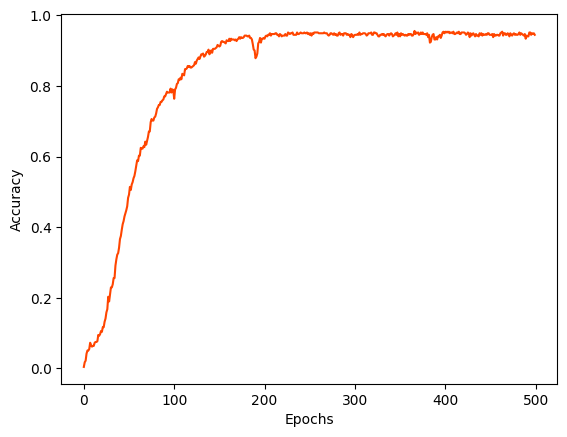

In [35]:
plt.plot(history.history['accuracy'],color="orangered")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

## Generating Text

With the model trained, you can now use it to make its own song! The process would look like:

1. Feed a seed text to initiate the process.
2. Model predicts the index of the most probable next word.
3. Look up the index in the reverse word index dictionary
4. Append the next word to the seed text.
5. Feed the result to the model again.

Steps 2 to 5 will repeat until the desired length of the song is reached. See how it is implemented in the code below:

In [66]:
seed_text = "Coding in python is"

next_words = 5

for _ in range(next_words):
    sequence = vectorize_layer(seed_text)
    sequence = tf.keras.utils.pad_sequences([sequence], maxlen=max_sequence_len-1, padding='pre')
    # Get the probablity of every word from the vocabulary
    probabilities = model.predict(sequence)
    
    # Find index of the word with the max probablity
    predicted = np.argmax(probabilities, axis=-1)[0]
    if predicted!=0:
        output_word = vocabulary[predicted]
        
        seed_text += " " + output_word
print(seed_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Coding in python is the row miss kerrigan fainted


    Clearly the sentence doesn't make sense but never the less it predicted something